Probabilitas prediksi [5, 1.5]: [[0.         0.90740741 0.09259259]]
Prediksi kelas [5, 1.5]: [1]


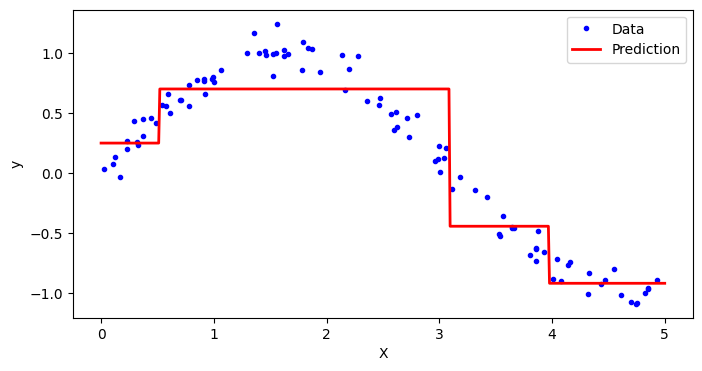

Best parameters: {'max_leaf_nodes': 6, 'min_samples_split': 2}
Accuracy on test set: 0.95


In [45]:
# 📌 Install dependensi (opsional, biasanya sudah tersedia di Colab)
# !pip install scikit-learn matplotlib numpy graphviz

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_moons
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
import graphviz

##############################################
# 1️⃣ Decision Tree Classifier - Iris Dataset
##############################################
iris = load_iris()
X = iris.data[:, 2:]  # petal length and width
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X, y)

# Visualisasi Tree dengan Graphviz
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    tree_clf,
    out_file=None,
    feature_names=iris.feature_names[2:],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)
graph = graphviz.Source(dot_data)
graph.render("iris_tree", format="png", cleanup=True)  # akan membuat file iris_tree.png

##############################################
# 2️⃣ Prediksi & Probabilitas
##############################################
print("Probabilitas prediksi [5, 1.5]:", tree_clf.predict_proba([[5, 1.5]]))
print("Prediksi kelas [5, 1.5]:", tree_clf.predict([[5, 1.5]]))

##############################################
# 3️⃣ Decision Tree dengan moons dataset (overfitting)
##############################################
X_moons, y_moons = make_moons(n_samples=100, noise=0.25, random_state=42)
tree_clf_moons = DecisionTreeClassifier(random_state=42)
tree_clf_moons.fit(X_moons, y_moons)

##############################################
# 4️⃣ Decision Tree dengan Regularisasi
##############################################
tree_clf_moons_reg = DecisionTreeClassifier(min_samples_leaf=4, random_state=42)
tree_clf_moons_reg.fit(X_moons, y_moons)

##############################################
# 5️⃣ Decision Tree Regression Example
##############################################
np.random.seed(42)
X_reg = np.sort(np.random.rand(100, 1) * 5, axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.randn(100) * 0.1

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_reg, y_reg)

X_plot = np.linspace(0, 5, 500).reshape(-1, 1)
y_pred = tree_reg.predict(X_plot)

plt.figure(figsize=(8, 4))
plt.plot(X_reg, y_reg, "b.", label="Data")
plt.plot(X_plot, y_pred, "r-", linewidth=2, label="Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

##############################################
# 6️⃣ Decision Tree + Grid Search (hyperparameter tuning)
##############################################
X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons, test_size=0.2, random_state=42)
param_grid = {"max_leaf_nodes": list(range(2, 100)), "min_samples_split": [2, 3, 4]}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=3, scoring="accuracy")
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_tree = grid_search.best_estimator_

y_pred_test = best_tree.predict(X_test)
print("Accuracy on test set:", accuracy_score(y_test, y_pred_test))

# 📚 Chapter 6 - Decision Trees

---

## 🔸 1. Apa Itu Decision Tree?
**Decision Tree** adalah algoritma Machine Learning yang dapat digunakan untuk **klasifikasi**, **regresi**, dan bahkan **multioutput tasks**.

**Kelebihan Decision Tree:**
- Mudah dipahami → **White-box model**
- Tidak memerlukan feature scaling
- Bisa menangani data numerik dan kategorikal

---

## 🔸 2. Cara Kerja Decision Tree
Decision Tree bekerja dengan cara:
1. Memilih fitur yang paling “informatif” untuk memisahkan data → menggunakan **Gini impurity** atau **Entropy**.
2. Membagi dataset menjadi 2 bagian.
3. Mengulangi langkah 1 & 2 hingga kondisi berhenti terpenuhi → misalnya **max_depth** tercapai.

**Gini Impurity Formula:**

\[
G_i = 1 - \sum_{k=1}^n (p_{i,k})^2
\]
- \(p_{i,k}\) = proporsi kelas k di node i.

**Entropy Formula:**

\[
H_i = -\sum_{k=1}^n p_{i,k} \cdot \log_2(p_{i,k})
\]
- Biasanya hasil mirip → Gini sedikit lebih cepat.

---

## 🔸 3. CART Algorithm
Scikit-Learn menggunakan algoritma **CART (Classification and Regression Tree)**:
- Hanya **binary splits** → selalu membagi jadi dua.
- Greedy → selalu memilih split terbaik *saat itu*, bukan mencari global optimal.

**Cost Function (Classification):**

\[
J(k, t_k) = \frac{m_{left}}{m} G_{left} + \frac{m_{right}}{m} G_{right}
\]

---

## 🔸 4. Probabilitas Prediksi
Untuk prediksi probabilitas kelas:

\[
P(k | \text{leaf node}) = \frac{\text{jumlah kelas k}}{\text{total instance di leaf}}
\]

---

## 🔸 5. Regularisasi (Mencegah Overfitting)
Tanpa batasan, Decision Tree **mudah overfitting**. Gunakan regularisasi:

| Hyperparameter         | Fungsi                                    |
|------------------------|-------------------------------------------|
| `max_depth`            | Batas kedalaman tree                     |
| `min_samples_split`    | Jumlah minimal sample agar node bisa split |
| `min_samples_leaf`     | Jumlah minimal sample di tiap leaf       |
| `max_leaf_nodes`       | Maksimum jumlah leaf node                |

---

## 🔸 6. Decision Tree for Regression
Decision Tree juga bisa digunakan untuk regresi → memprediksi **nilai kontinu**.

**Cost Function (Regression):**

\[
J(k, t_k) = \frac{m_{left}}{m} MSE_{left} + \frac{m_{right}}{m} MSE_{right}
\]

- Model regresi menghasilkan prediksi berupa rata-rata nilai target di leaf node.

---

## 🔸 7. Kelemahan Decision Tree
- **Overfitting** jika tidak diregulasi
- **Sensitif terhadap perubahan data** → hasil training bisa sangat berbeda
- **Decision boundary tegak lurus axis** → sensitif terhadap rotasi data

**Solusi:** Gunakan **Random Forest** → akan dibahas di **Chapter 7**.

---

## ⚖️ Bias-Variance Trade-off
| Bias Tinggi (Underfitting) | Variance Tinggi (Overfitting) |
| -------------------------- | ----------------------------- |
| Tree terlalu dangkal       | Tree terlalu dalam            |

---

## ✅ Kesimpulan
- ✅ **Cocok untuk dataset dengan hubungan yang tidak linear**
- ✅ **Tidak memerlukan scaling**
- ❗ **Harus diregulasi untuk mencegah overfitting**
- ✅ **Mudah dipahami & interpretasi**

